In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

Saving retail_sales_dataset.csv to retail_sales_dataset.csv


In [5]:
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [ ]:
df=pd.read_csv('retail_sales_dataset.csv')
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [7]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


PROBLEM 1= Why does a category generate more sales?

In [8]:
import pandas as pd

category_revenue = df.groupby('Product Category')['Total Amount'].sum().reset_index()
category_revenue = category_revenue.sort_values(by='Total Amount', ascending=False)

print(category_revenue)

  Product Category  Total Amount
2      Electronics        156905
1         Clothing        155580
0           Beauty        143515


In [9]:
analysis = df.groupby('Product Category').agg({
    'Price per Unit': 'mean',
    'Quantity': 'mean',
    'Transaction ID': 'count',
    'Customer ID': 'nunique',
    'Total Amount': 'sum'
}).reset_index()

analysis.columns = [
    'Category',
    'Avg_Price',
    'Avg_Quantity',
    'Num_Transactions',
    'Num_Customers',
    'Total_Revenue'
]

print(analysis)

      Category   Avg_Price  Avg_Quantity  Num_Transactions  Num_Customers  \
0       Beauty  184.055375      2.511401               307            307   
1     Clothing  174.287749      2.547009               351            351   
2  Electronics  181.900585      2.482456               342            342   

   Total_Revenue  
0         143515  
1         155580  
2         156905  


In [10]:
analysis['Revenue_per_Transaction'] = analysis['Total_Revenue'] / analysis['Num_Transactions']
analysis['Revenue_per_Customer'] = analysis['Total_Revenue'] / analysis['Num_Customers']
analysis['Transactions_per_Customer'] = analysis['Num_Transactions'] / analysis['Num_Customers']

In [11]:
analysis = analysis.sort_values(by='Total_Revenue', ascending=False)

print(analysis)

      Category   Avg_Price  Avg_Quantity  Num_Transactions  Num_Customers  \
2  Electronics  181.900585      2.482456               342            342   
1     Clothing  174.287749      2.547009               351            351   
0       Beauty  184.055375      2.511401               307            307   

   Total_Revenue  Revenue_per_Transaction  Revenue_per_Customer  \
2         156905               458.786550            458.786550   
1         155580               443.247863            443.247863   
0         143515               467.475570            467.475570   

   Transactions_per_Customer  
2                        1.0  
1                        1.0  
0                        1.0  


In [12]:
top_customers = df.groupby(['Product Category', 'Customer ID'])['Total Amount'].sum().reset_index()

# Top 10% customers contribution
def concentration(group):
    group = group.sort_values(by='Total Amount', ascending=False)
    top_10_percent = int(len(group) * 0.1)
    return group.head(top_10_percent)['Total Amount'].sum() / group['Total Amount'].sum()

concentration_analysis = top_customers.groupby('Product Category').apply(concentration).reset_index()
concentration_analysis.columns = ['Category', 'Top_10pct_Revenue_Share']

print(concentration_analysis)

      Category  Top_10pct_Revenue_Share
0       Beauty                 0.358848
1     Clothing                 0.386296
2  Electronics                 0.383672


/tmp/ipykernel_11246/1219927199.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  concentration_analysis = top_customers.groupby('Product Category').apply(concentration).reset_index()


Visuals analysis

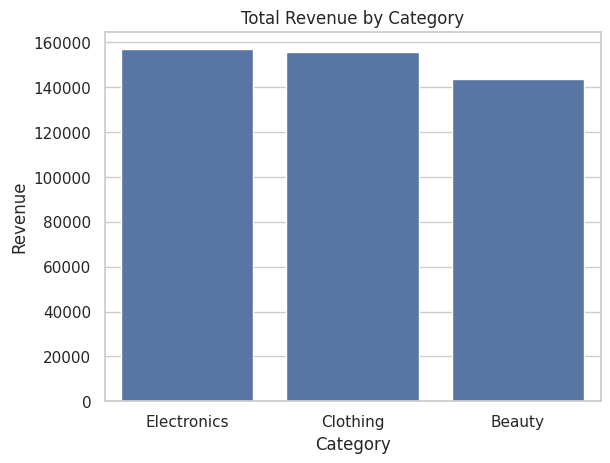

In [17]:
plt.figure()
sns.barplot(data=analysis, x='Category', y='Total_Revenue')

plt.title('Total Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.tight_layout()

plt.show()

Question:

Which category earns the most?

insight(Electronics leads revenue, but the gap with Clothing is minimal, indicating no clear dominant category and a highly competitive balance across segments.)

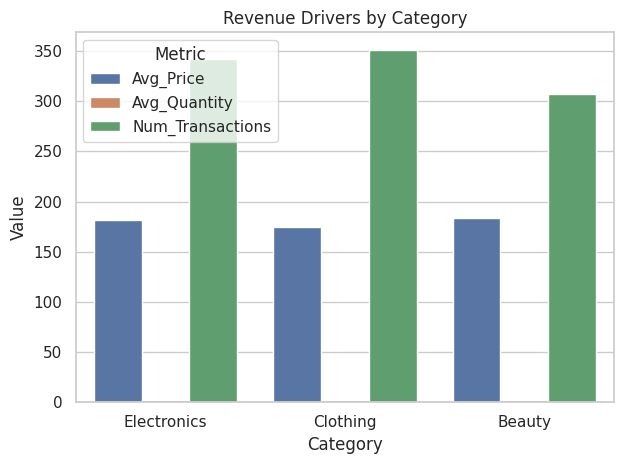

In [31]:
analysis_melted = analysis.melt(
    id_vars='Category',
    value_vars=['Avg_Price', 'Avg_Quantity', 'Num_Transactions'],
    var_name='Metric',
    value_name='Value'
)

plt.figure()
sns.barplot(data=analysis_melted, x='Category', y='Value', hue='Metric')

plt.title('Revenue Drivers by Category')
plt.xlabel('Category')
plt.tight_layout()

plt.show()

Question:

Is revenue driven by price, quantity, or transactions?

insight(Clothing’s performance is driven by higher transaction volume rather than pricing, while Beauty relies more on higher prices, showing fundamentally different revenue strategies.)

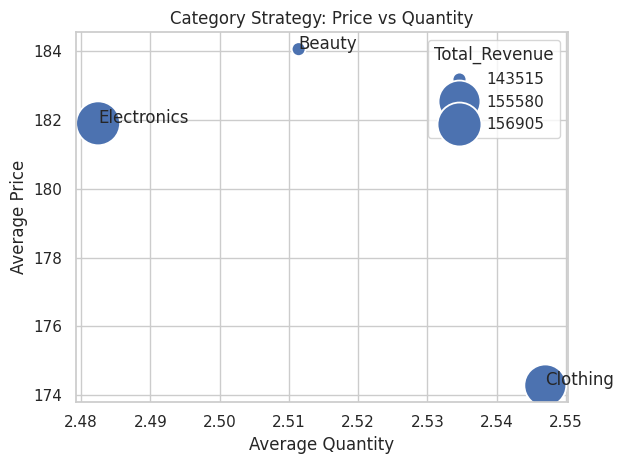

In [27]:
plt.figure()

sns.scatterplot(
    data=analysis,
    x='Avg_Quantity',
    y='Avg_Price',
    size='Total_Revenue',
    sizes=(100, 1000)
)

for i in range(len(analysis)):
    plt.text(
        analysis['Avg_Quantity'][i],
        analysis['Avg_Price'][i],
        analysis['Category'][i]
    )

plt.title('Category Strategy: Price vs Quantity')
plt.xlabel('Average Quantity')
plt.ylabel('Average Price')
plt.tight_layout()

plt.show()

Question:

What strategy does each category follow?

insight(Beauty follows a premium pricing strategy, Clothing operates on high-volume sales, and Electronics sits in between, indicating distinct growth levers for each category.)

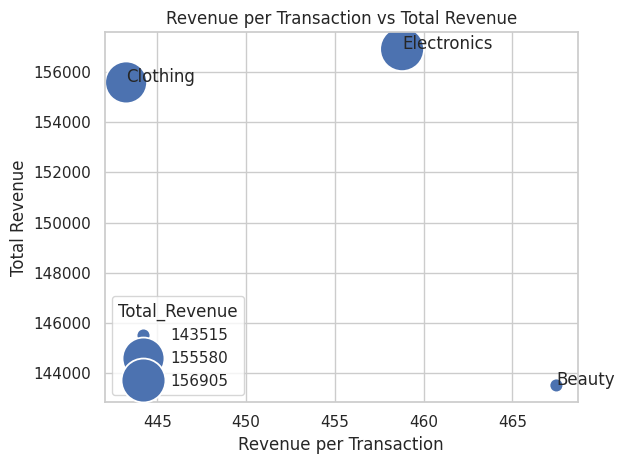

In [24]:
plt.figure()

sns.scatterplot(
    data=analysis,
    x='Revenue_per_Transaction',
    y='Total_Revenue',
    size='Total_Revenue',
    sizes=(100, 1000)
)

for i in range(len(analysis)):
    plt.text(
        analysis['Revenue_per_Transaction'][i],
        analysis['Total_Revenue'][i],
        analysis['Category'][i]
    )

plt.title('Revenue per Transaction vs Total Revenue')
plt.xlabel('Revenue per Transaction')
plt.ylabel('Total Revenue')
plt.tight_layout()

plt.show()

Question:

Do high-value transactions lead to high total revenue?

insight(Beauty generates the highest value per transaction but lags in total revenue due to fewer transactions, suggesting growth depends on increasing purchase frequency.)

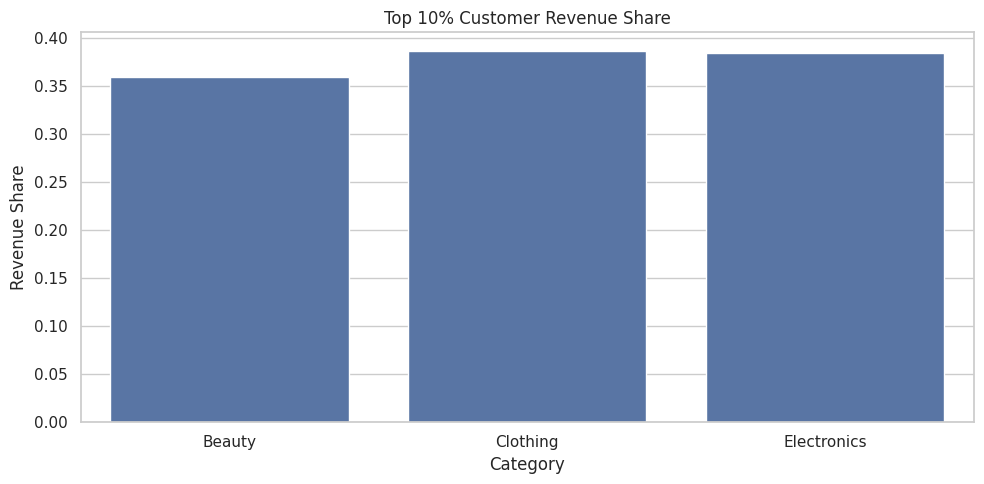

In [25]:
plt.figure(figsize=(10,5))

sns.barplot(data=concentration_analysis, x='Category', y='Top_10pct_Revenue_Share')

plt.title('Top 10% Customer Revenue Share')
plt.xlabel('Category')
plt.ylabel('Revenue Share')
plt.tight_layout()

plt.show()

Question:

Is revenue dependent on a few customers?

insight(Clothing and Electronics show slightly higher dependence on top customers, indicating moderate concentration risk, while Beauty’s revenue is more evenly distributed.)

# Retail Sales Data Analysis And Business Insight

This project focuses on analyzing retail sales data to identify customer purchasing behavior, product category performance, and revenue trends using Python data analytics libraries such as Pandas, Matplotlib, and Seaborn.

The dataset was cleaned and explored to understand how different product categories contribute to total sales and how customer transactions affect overall business performance. Several visualizations were created to compare category-wise revenue, transaction volume, and customer concentration.

Key Analysis Performed

* Data cleaning and preprocessing
* Category-wise sales analysis
* Revenue comparison between product categories
* Customer transaction analysis
* Visualization of sales trends and business patterns
* Identification of high-performing categories

Major Findings

The analysis revealed that Electronics generated the highest overall revenue, while Clothing maintained strong sales through higher transaction frequency. Beauty products showed comparatively fewer purchases but higher revenue per transaction, indicating a premium pricing strategy.

The project also highlighted that categories with consistent customer purchases can compete strongly even when individual transaction values are lower. Revenue distribution analysis showed that some categories rely heavily on top customers, while others maintain a more balanced customer base.

Business Insights

* High transaction volume plays an important role in increasing long-term revenue.
* Premium-priced products can generate strong revenue even with fewer sales.
* Businesses should focus on both customer retention and pricing strategy.
* Category-level analysis helps companies improve decision-making and optimize sales strategies.

Technologies Used

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Google Colab / Jupyter Notebook

Conclusion

This project demonstrates how data analytics can be used to extract meaningful business insights from retail sales data. The analysis helps businesses understand customer behavior, evaluate category performance, and support data-driven decision making.


